In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP_new import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.cosmology import Planck18, FlatLambdaCDM
cosmo = Planck18

In [2]:
filenames = {
    'all' : './catalogs/test_all_multicomp_0722.fits',
    'dps' : './catalogs/test_dps_multicomp_0722.fits',
}
FIT = FitSpectrum()
DP  = DP()

In [3]:
stellar = fits.open('/Users/hyp0515/data/dr1_galaxy_stellarmass_lineinfo_v1.0_extracted.fits')


In [4]:
stellar[1].columns

ColDefs(
    name = 'TARGETID'; format = 'K'; null = 999999
    name = 'SURVEY'; format = '7A'
    name = 'PROGRAM'; format = '6A'
    name = 'HEALPIX'; format = 'J'; null = 999999
    name = 'Z'; format = 'D'
    name = 'ZERR'; format = 'D'
    name = 'TARGET_RA'; format = 'D'; unit = 'deg'
    name = 'TARGET_DEC'; format = 'D'; unit = 'deg'
    name = 'OBJTYPE'; format = '3A'
    name = 'RELEASE'; format = 'I'; null = 16959
    name = 'BRICKID'; format = 'J'; null = 999999
    name = 'BRICK_OBJID'; format = 'J'; null = 999999
    name = 'MORPHTYPE'; format = '4A'
    name = 'EBV'; format = 'E'; unit = 'mag'
    name = 'FLUX_G'; format = 'E'; unit = 'nanomaggy'
    name = 'FLUX_R'; format = 'E'; unit = 'nanomaggy'
    name = 'FLUX_Z'; format = 'E'; unit = 'nanomaggy'
    name = 'FLUX_W1'; format = 'E'; unit = 'nanomaggy'
    name = 'FLUX_W2'; format = 'E'; unit = 'nanomaggy'
    name = 'FLUX_IVAR_G'; format = 'E'; unit = 'nanomaggy-2'
    name = 'FLUX_IVAR_R'; format = 'E'; unit = 'na

In [5]:
stellar_df = Table(stellar['EMLINES_MASS'].data)[['TARGETID', 'Z', 'MORPHTYPE', 'SERSIC', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'V0_SL', 'VD_SL']].to_pandas()

In [6]:
criteria = (stellar_df['SHAPE_E1'] != 0) & (stellar_df['SHAPE_E2'] != 0) & (stellar_df['VD_SL'] != 0)
stellar_df = stellar_df[criteria]
stellar_df.head(30)

,TARGETID,Z,MORPHTYPE,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,V0_SL,VD_SL
0,39627739380056154,0.296782,DEV,4.000000,1.577094,-0.119644,0.118579,0.000000,145.330002
2,39627739380056420,0.102005,SER,0.722487,2.256895,-0.635100,0.242358,42.830002,2.770000
4,39627739380056768,0.102814,EXP,1.000000,3.253860,-0.644405,0.164896,35.160000,72.139999
5,39627739380056864,0.167324,SER,1.557097,1.637565,0.036330,-0.328371,39.380001,78.610001
6,39627739380057310,0.088938,SER,1.770263,1.590040,-0.119267,-0.118676,10.880000,141.919998
8,39627739380057537,0.168780,SER,2.173721,3.023373,-0.310598,0.295186,81.470001,179.710007
9,39627739380057549,0.169113,DEV,4.000000,1.145453,-0.002011,0.126223,93.050003,168.850006
10,39627739380057597,0.168429,SER,5.246174,13.624000,0.067676,-0.020047,98.769997,200.630005
11,39627739380057673,0.168938,SER,2.725922,1.737141,0.397180,-0.332625,82.930000,213.830002
12,39627739380057686,0.168038,SER,2.125000,1.647249,-0.549873,-0.087498,42.330002,134.710007


In [7]:
dp_parent, dp_components, model_cube = DP.extract_fits_data(filenames['dps'])
dp_parent.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3726_FLUX_TOT,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT
0,39627739380057763,177.068542,-1.882260,0.242461,10.436480,-0.020428,2,2,1048.371948,987.857422,...,10.882325,14.484303,14.373573,1.456799,4.412641,21.363346,65.510559,112.543510,18.831467,12.215933
1,39627739380059797,177.158051,-1.894803,0.191538,10.211300,0.980484,2,2,1094.034912,1033.963867,...,11.507749,15.316737,25.882032,3.799332,11.508166,22.408655,68.715996,169.968246,33.906574,21.665701
2,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,2,2,888.517456,827.970520,...,1.998460,2.659936,5.458763,0.304648,0.922778,3.838368,11.770330,29.707720,6.509788,3.707097
3,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,2,2,1219.361694,1159.901855,...,24.250002,32.276592,42.338837,4.612947,13.972602,31.143583,95.501595,223.526062,38.995651,25.629316
4,39627739384252917,177.358017,-1.933391,0.082934,10.019835,-1.504955,2,2,850.615601,791.327698,...,5.098344,6.785862,13.314130,1.673348,5.068565,7.402871,22.700853,49.067883,2.614727,3.684467


In [8]:
stellar_df = stellar_df[stellar_df['TARGETID'].isin(dp_parent['TARGETID'])]

In [9]:
stellar_df['R_PHYSICAL'] = stellar_df['SHAPE_R'] / 60 * cosmo.kpc_proper_per_arcmin(stellar_df['Z']).value
b_a_ratio = ((1-np.sqrt(stellar_df['SHAPE_E1']**2 + stellar_df['SHAPE_E2']**2)) /\
    (1+np.sqrt(stellar_df['SHAPE_E1']**2 + stellar_df['SHAPE_E2']**2)))
stellar_df['b_a_ratio'] = b_a_ratio
stellar_df['FIBER'] = (1.5 * np.ones(len(stellar_df))) / 60 * cosmo.kpc_proper_per_arcmin(stellar_df['Z']).value

In [10]:
stellar_df.head()

,TARGETID,Z,MORPHTYPE,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,V0_SL,VD_SL,R_PHYSICAL,b_a_ratio,FIBER
13,39627739380057763,0.242461,SER,5.779601,1.626138,0.100888,0.104436,70.879997,32.099998,6.418102,0.746408,5.920257
27,39627739380060210,0.238389,SER,2.648419,1.265829,0.124558,0.147421,71.870003,124.010002,4.933502,0.676451,5.846173
32,39627739380061198,0.103277,SER,1.779606,0.794439,0.124741,-0.186262,77.089996,100.040001,1.558311,0.633755,2.942288
40,39627739384253125,0.082785,SER,1.508034,1.499528,0.345041,0.333224,81.769997,62.330002,2.414504,0.351645,2.415264
42,39627739384253866,0.322677,SER,1.109368,1.686460,-0.141895,-0.031302,0.000000,200.000000,8.146757,0.746257,7.246029


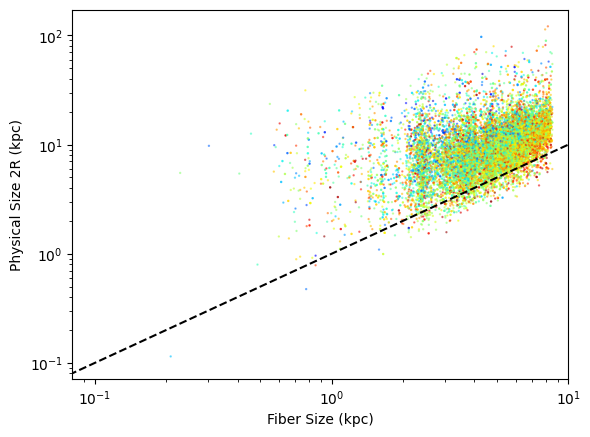

In [11]:
plt.scatter(stellar_df['FIBER'], 2*stellar_df['R_PHYSICAL'], s=0.5, alpha=0.5, c=stellar_df['b_a_ratio'], cmap='jet', vmin=0, vmax=1)
plt.plot(np.linspace(0, 10, 100), np.linspace(0, 10, 100), color='k', linestyle='--')
plt.yscale('log')
plt.xscale('log')
plt.xlim(right=10)
plt.xlabel('Fiber Size (kpc)')
plt.ylabel('Physical Size 2R (kpc)')
plt.show()

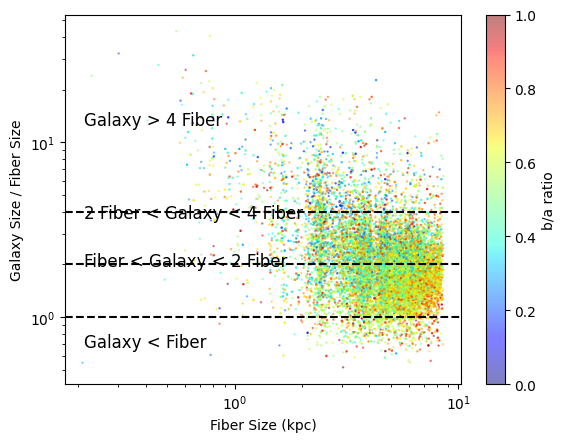

In [12]:
plt.scatter(stellar_df['FIBER'], 2*stellar_df['R_PHYSICAL']/stellar_df['FIBER'], s=0.5, alpha=0.5, c=stellar_df['b_a_ratio'], cmap='jet', vmin=0, vmax=1)
plt.colorbar(label='b/a ratio')
plt.text(0.05, 0.1, 'Galaxy < Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(1, color='k', linestyle='--')
plt.text(0.05, 0.32, 'Fiber < Galaxy < 2 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(2, color='k', linestyle='--')
plt.text(0.05, 0.45, '2 Fiber < Galaxy < 4 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(4, color='k', linestyle='--')
plt.text(0.05, 0.7, 'Galaxy > 4 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Fiber Size (kpc)')
plt.ylabel('Galaxy Size / Fiber Size')
plt.show()

In [13]:
stellar_df['N_COMP'] = dp_parent['N_COMP_FIT']
stellar_df['LOGM'] = dp_parent['LOGM']
stellar_df['LOGSFR'] = dp_parent['LOGSFR']

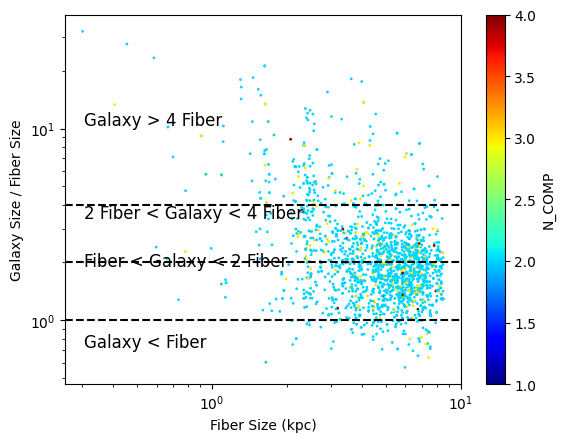

In [14]:
plt.scatter(stellar_df['FIBER'], 2*stellar_df['R_PHYSICAL']/stellar_df['FIBER'], s=1, alpha=1, c=stellar_df['N_COMP'], cmap='jet', vmin=1, vmax=4)
plt.colorbar(label='N_COMP')
plt.text(0.05, 0.1, 'Galaxy < Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(1, color='k', linestyle='--')
plt.text(0.05, 0.32, 'Fiber < Galaxy < 2 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(2, color='k', linestyle='--')
plt.text(0.05, 0.45, '2 Fiber < Galaxy < 4 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(4, color='k', linestyle='--')
plt.text(0.05, 0.7, 'Galaxy > 4 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Fiber Size (kpc)')
plt.ylabel('Galaxy Size / Fiber Size')
plt.show()

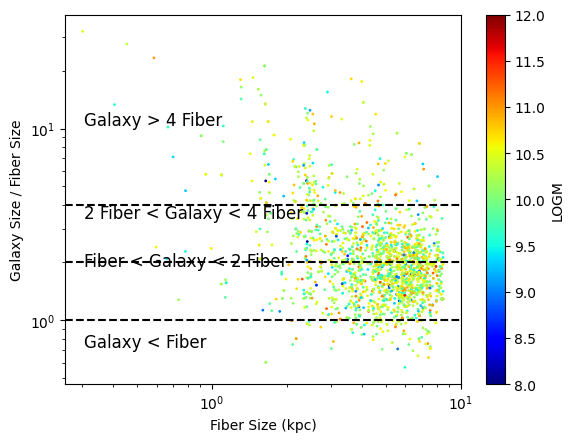

In [15]:
plt.scatter(stellar_df['FIBER'], 2*stellar_df['R_PHYSICAL']/stellar_df['FIBER'], s=1, alpha=1, c=stellar_df['LOGM'], cmap='jet', vmin=8, vmax=12)
plt.colorbar(label='LOGM')
plt.text(0.05, 0.1, 'Galaxy < Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(1, color='k', linestyle='--')
plt.text(0.05, 0.32, 'Fiber < Galaxy < 2 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(2, color='k', linestyle='--')
plt.text(0.05, 0.45, '2 Fiber < Galaxy < 4 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(4, color='k', linestyle='--')
plt.text(0.05, 0.7, 'Galaxy > 4 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Fiber Size (kpc)')
plt.ylabel('Galaxy Size / Fiber Size')
plt.show()

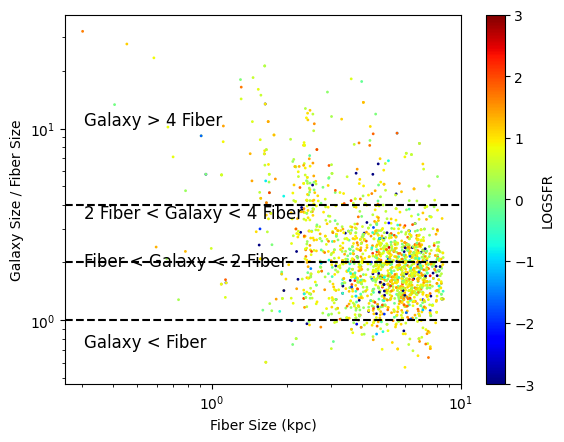

In [16]:
plt.scatter(stellar_df['FIBER'], 2*stellar_df['R_PHYSICAL']/stellar_df['FIBER'], s=1, alpha=1, c=stellar_df['LOGSFR'], cmap='jet', vmin=-3, vmax=3)
plt.colorbar(label='LOGSFR')
plt.text(0.05, 0.1, 'Galaxy < Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(1, color='k', linestyle='--')
plt.text(0.05, 0.32, 'Fiber < Galaxy < 2 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(2, color='k', linestyle='--')
plt.text(0.05, 0.45, '2 Fiber < Galaxy < 4 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.axhline(4, color='k', linestyle='--')
plt.text(0.05, 0.7, 'Galaxy > 4 Fiber', fontsize=12, ha='left', transform=plt.gca().transAxes)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Fiber Size (kpc)')
plt.ylabel('Galaxy Size / Fiber Size')
plt.show()

In [17]:
print(stellar_df['N_COMP'].value_counts())

N_COMP
2.0    1640
3.0     177
4.0      17
Name: count, dtype: int64


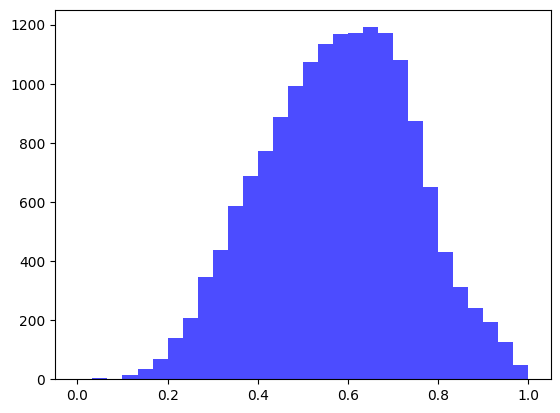

In [18]:
plt.hist(stellar_df['b_a_ratio'], bins=30, range=(0, 1), color='blue', alpha=0.7)
plt.show()

In [19]:
stellar_df.sort_values(by='b_a_ratio', ascending=False).head(30)

,TARGETID,Z,MORPHTYPE,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,V0_SL,VD_SL,R_PHYSICAL,b_a_ratio,FIBER,N_COMP,LOGM,LOGSFR
76358,39627787761353502,0.214356,SER,6.000000,0.944131,-0.001394,-0.002112,79.339996,32.820000,3.395341,0.994952,5.394394,NaN,NaN,NaN
76356,39627787761353502,0.214354,SER,6.000000,0.944131,-0.001394,-0.002112,78.610001,75.699997,3.395316,0.994952,5.394354,NaN,NaN,NaN
76357,39627787761353502,0.214375,SER,6.000000,0.944131,-0.001394,-0.002112,68.940002,50.360001,3.395569,0.994952,5.394755,NaN,NaN,NaN
21722,39627752181074689,0.309025,SER,5.183123,1.250077,-0.001912,0.005200,15.860000,128.990005,5.864830,0.988980,7.037363,NaN,NaN,NaN
21723,39627752181074689,0.309004,SER,5.183123,1.250077,-0.001912,0.005200,73.279999,193.380005,5.864555,0.988980,7.037033,NaN,NaN,NaN
104534,39627805822030894,0.328125,SER,3.033558,2.584713,-0.003457,-0.005346,91.019997,94.559998,12.626278,0.987347,7.327473,NaN,NaN,NaN
69950,39627782136794481,0.089495,SER,2.143131,1.467134,0.001452,-0.006270,91.389999,93.870003,2.533909,0.987211,2.590673,NaN,NaN,NaN
46400,39627769881038040,0.170042,SER,3.360732,0.830862,-0.007082,0.000990,83.169998,60.970001,2.488189,0.985801,4.492060,NaN,NaN,NaN
49845,39627770187224787,0.118270,SER,3.846751,2.533549,0.007297,-0.001220,62.639999,185.009995,5.593931,0.985312,3.311914,NaN,NaN,NaN
49844,39627770187224787,0.118298,SER,3.846751,2.533549,0.007297,-0.001220,56.189999,189.880005,5.595078,0.985312,3.312593,NaN,NaN,NaN


In [26]:
id = 39627776281545012
example_df = dp_parent[dp_parent['TARGETID']==id].copy()
print(image_link(example_df['RA'], example_df['DEC'], plot=True, save_image=True, fname=f"./figures/example_image.jpg", side_arcmin=0.33))

# print(spectrum_link(id))

HTTPError: 400 Client Error: Bad Request for url: https://www.legacysurvey.org/viewer/cutout.jpg?ra=7403%20%20%20%20216.617752%0AName:%20RA,%20dtype:%20float32&dec=7403%20%20%20-0.570268%0AName:%20DEC,%20dtype:%20float32&pixscale=0.11&layer=hsc-dr3&size=200